## UTILIDADES

In [7]:
import numpy as np
import pandas as pd
import holidays

def add_cyclic_features(df):
  df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
  df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
  df['Day_sin'] = np.sin(2 * np.pi * df['Day'] / 31)
  df['Day_cos'] = np.cos(2 * np.pi * df['Day'] / 31)
  return df

def add_holiday_feature(df):
  uk_holidays = holidays.UK(years=range(2000, 2030))
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
  df['IsHoliday'] = df['InvoiceDate'].apply(lambda x: 1 if x.date() in uk_holidays else 0)
  return df

def add_lags(df, lags=[1, 7, 30]):
  for lag in lags:
      df[f'TotalSales_Lag{lag}'] = df['TotalSales'].shift(lag)
  return df

def add_rolling_means(df, windows=[7, 30]):
    for window in windows:
        df[f'TotalSales_Rolling{window}'] = df['TotalSales'].rolling(window).mean()
    return df

## Primera versión

In [19]:
import pandas as pd
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df_to_train = pd.read_csv("../../data/dataset_training.csv", parse_dates=['InvoiceDate'])
df_to_train = add_cyclic_features(df_to_train)
df_to_train = add_holiday_feature(df_to_train)
df_to_train = add_lags(df_to_train)
df_to_train = add_rolling_means(df_to_train)

df_to_train['IsMonthEnd'] = df_to_train['InvoiceDate'].dt.is_month_end.astype(int)
df_to_train['IsWeekend'] = (df_to_train['DayOfWeek'] >= 5).astype(int)

X_to_train =  df_to_train[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsHoliday', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']]
Y_to_train = df_to_train['TotalSales'].values.reshape(-1, 1)

# Normalizar los datos
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_to_train = scaler_X.fit_transform(X_to_train)
Y_to_train = scaler_Y.fit_transform(Y_to_train)

# Entrenar el modelo
tf.random.set_seed(42)
model = keras.Sequential([
  keras.layers.Dense(128, activation='relu', input_shape=(X_to_train.shape[1],)),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dense(1)
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
model.fit(X_to_train, Y_to_train, epochs=150, batch_size=32, verbose=0)

/mnt/c/Users/Wiler/Documents/yo/NKIA/TFM/regresion/.regression_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
df_to_test = pd.read_csv("../../data/dataset_prediction.csv", parse_dates=['InvoiceDate'])
df_to_test = add_cyclic_features(df_to_test)
df_to_test = add_holiday_feature(df_to_test)
df_to_test = add_lags(df_to_test)
df_to_test = add_rolling_means(df_to_test)

df_to_test['IsMonthEnd'] = df_to_test['InvoiceDate'].dt.is_month_end.astype(int)
df_to_test['IsWeekend'] = (df_to_test['DayOfWeek'] >= 5).astype(int)

X_to_test =  df_to_test[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsHoliday', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']]
Y_to_test = df_to_test['TotalSales'].values.reshape(-1, 1)

# Normalizar los datos de prueba
X_to_test = scaler_X.transform(X_to_test)
Y_to_test = scaler_Y.transform(Y_to_test)

# Hacer predicciones
predictions = model.predict(X_to_test)
predictions = scaler_Y.inverse_transform(predictions)
Y_to_test = scaler_Y.inverse_transform(Y_to_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


- Hacemos las métricas para evaluar el rendimiento

RMSE: 10170.43
MAE: 7867.67


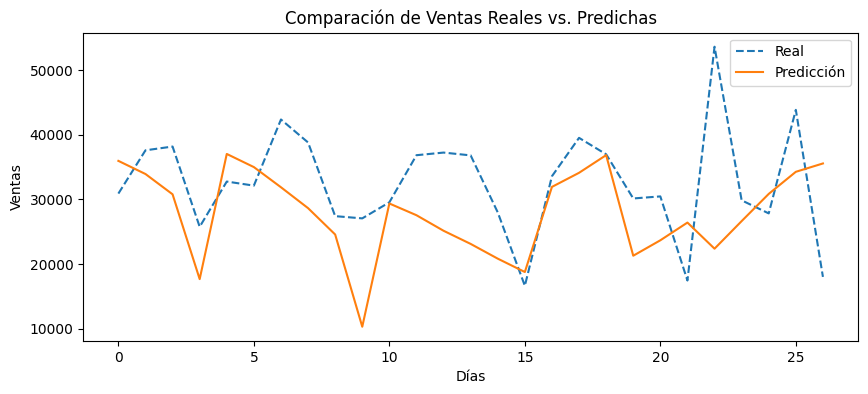

In [27]:
mae = mean_absolute_error(Y_to_test, predictions)
rmse = np.sqrt(mean_squared_error(Y_to_test, predictions))
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(Y_to_test, label="Real", linestyle="dashed")
plt.plot(predictions, label="Predicción")
plt.legend()
plt.title("Comparación de Ventas Reales vs. Predichas")
plt.xlabel("Días")
plt.ylabel("Ventas")
plt.show()